# Chapter 3 — Fourier Analysis, FFT & Time–Frequency

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch03_fourier_fft.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch03_fourier_fft.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch03_fourier_fft.ipynb)

> **Motivating question.** How do we see the delta, theta, alpha and spindle 'notes' hidden inside a raw EEG trace?

## What this notebook demonstrates

- Fourier series, the Gibbs phenomenon, and the FFT's O(N log N) win
- Frequency resolution Δf = fs/N vs zero-padding (interpolation ≠ resolution)
- The STFT and the spectrogram; the uncertainty trade-off
- 2-D FFT of an image: magnitude vs phase, and the inverse FFT
- One operation, two domains: convolve↔multiply, smooth↔low-pass

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | full (synthetic data, NumPy/SciPy/sklearn only) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from scipy import signal as sig

CH = 3


def _mag_spectrum(x, fs):
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft((x - x.mean()) * w)
    f = np.fft.rfftfreq(n, 1 / fs)
    mag = np.abs(X) / n
    return f, mag

## 3.1  fourier series

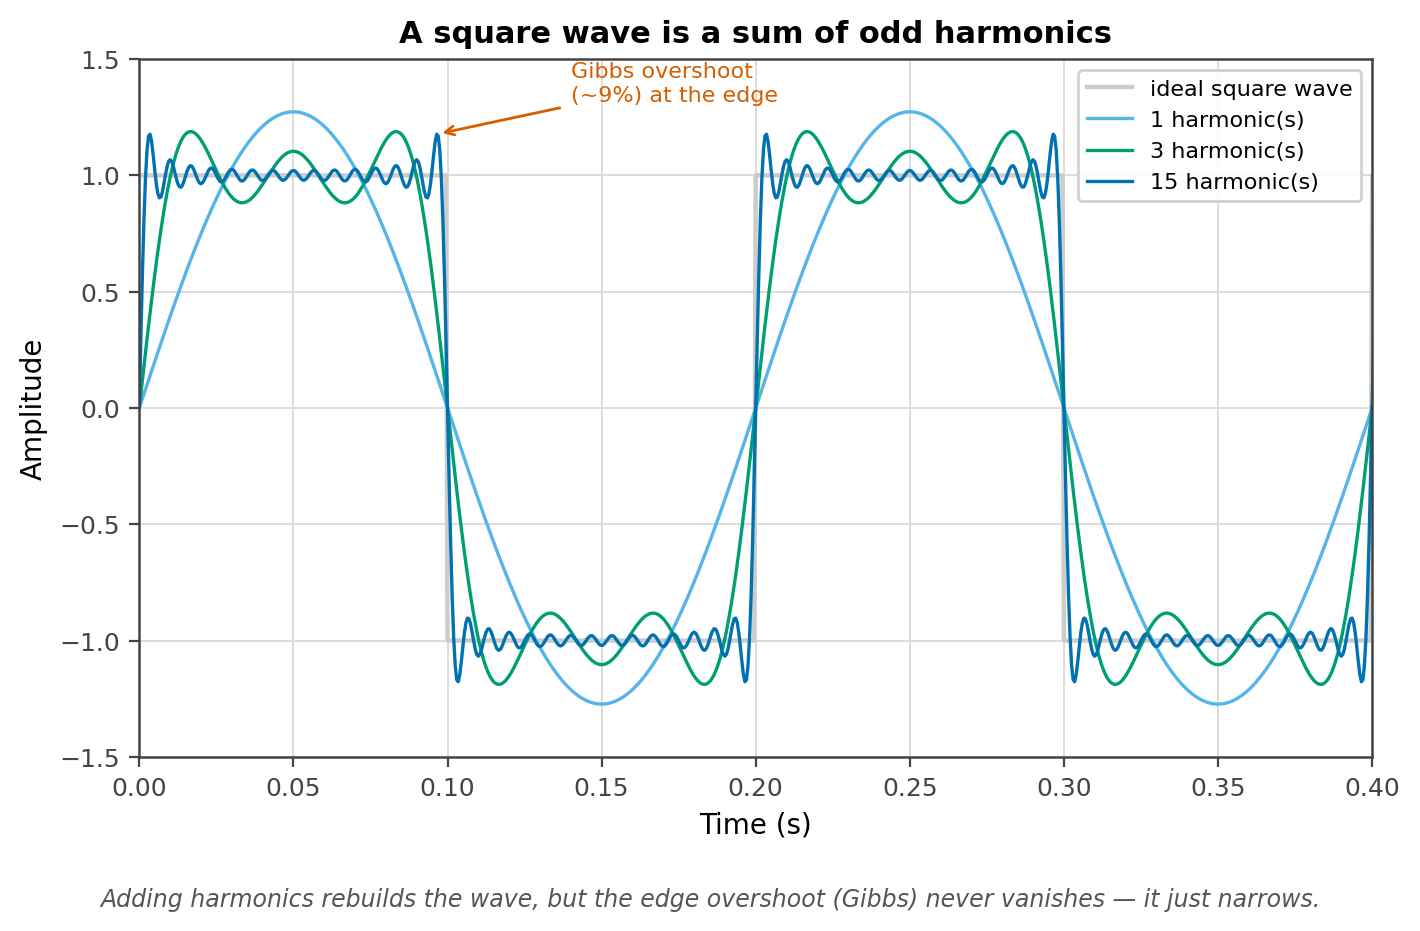

In [3]:
fs = 2000.0
t = np.arange(int(1.0 * fs)) / fs
f0 = 5.0
square = sig.square(2 * np.pi * f0 * t)
fig, ax = bs.newfig(w=7.2, h=4.4)
ax.plot(t, square, color=bs.C["lightgrey"], lw=1.6, label="ideal square wave")
for N, c in [(1, bs.C["sky"]), (3, bs.C["green"]), (15, bs.C["blue"])]:
    s = np.zeros_like(t)
    for k in range(1, N + 1):
        h = 2 * k - 1
        s += (4 / np.pi) * np.sin(2 * np.pi * f0 * h * t) / h
    ax.plot(t, s, color=c, lw=1.2, label=f"{N} harmonic(s)")
ax.set_xlim(0, 0.4)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("A square wave is a sum of odd harmonics")
ax.legend(loc="upper right", fontsize=8)
ax.annotate("Gibbs overshoot\n(~9%) at the edge", xy=(0.0965, 1.177),
            xytext=(0.14, 1.32), fontsize=8, color=bs.C["red"],
            arrowprops=dict(arrowstyle="->", color=bs.C["red"], lw=1.0))
bs.takeaway(fig, "Adding harmonics rebuilds the wave, but the edge overshoot "
                 "(Gibbs) never vanishes — it just narrows.")
plt.tight_layout()
plt.show()

## 3.2  fft biosignals

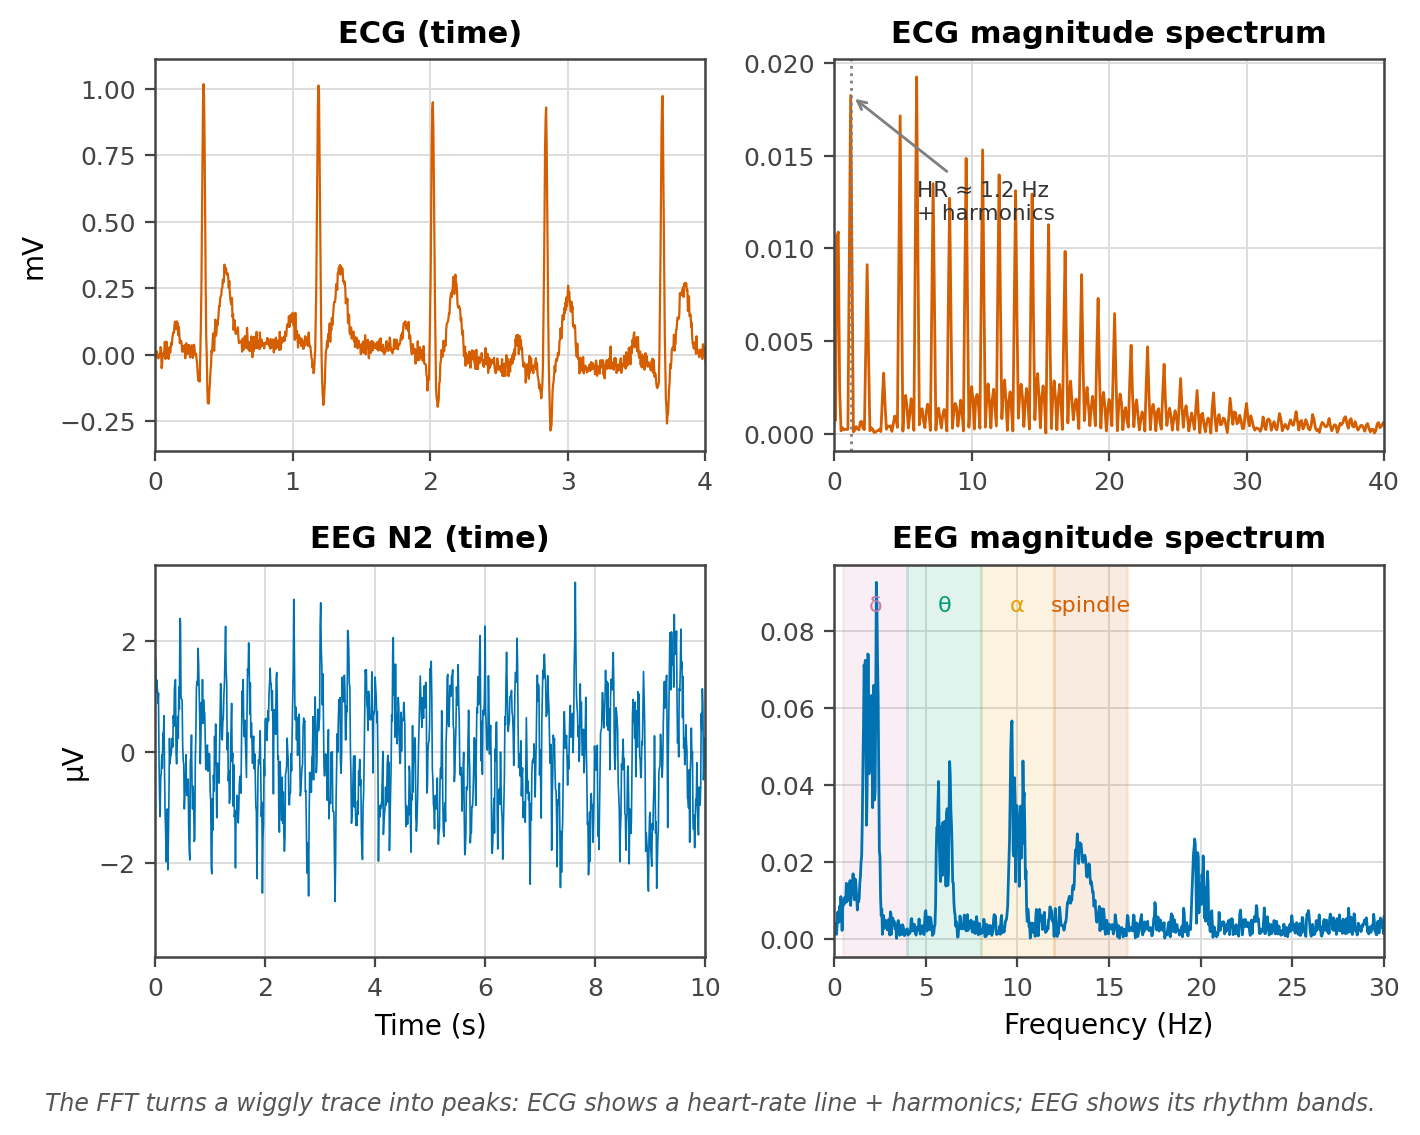

In [4]:
fig, ax = bs.newfig(w=7.2, h=5.4, nrows=2, ncols=2)
# ECG
t, x = bio.ecg(duration=10.0, fs=256, hr=72)
ax[0, 0].plot(t, x, color=bs.C["red"], lw=0.8)
ax[0, 0].set_title("ECG (time)")
ax[0, 0].set_xlim(0, 4)
ax[0, 0].set_ylabel("mV")
f, m = _mag_spectrum(x, 256)
ax[0, 1].plot(f, m, color=bs.C["red"], lw=1.0)
ax[0, 1].set_xlim(0, 40)
ax[0, 1].set_title("ECG magnitude spectrum")
ax[0, 1].axvline(72 / 60, color=bs.C["grey"], ls=":", lw=1.0)
ax[0, 1].annotate("HR ≈ 1.2 Hz\n+ harmonics", xy=(1.2, m[np.argmin(abs(f - 1.2))]),
                  xytext=(6, 0.6 * m.max()), fontsize=7.8, color="#333333",
                  arrowprops=dict(arrowstyle="->", color=bs.C["grey"]))
# EEG (N2)
t, x = bio.eeg(duration=30.0, fs=100, stage="N2")
ax[1, 0].plot(t, x, color=bs.C["blue"], lw=0.6)
ax[1, 0].set_title("EEG N2 (time)")
ax[1, 0].set_xlim(0, 10)
ax[1, 0].set_xlabel("Time (s)")
ax[1, 0].set_ylabel("µV")
f, m = _mag_spectrum(x, 100)
ax[1, 1].plot(f, m, color=bs.C["blue"], lw=1.0)
ax[1, 1].set_xlim(0, 30)
ax[1, 1].set_xlabel("Frequency (Hz)")
ax[1, 1].set_title("EEG magnitude spectrum")
for lo, hi, name, c in [(0.5, 4, "δ", bs.C["purple"]), (4, 8, "θ", bs.C["green"]),
                        (8, 12, "α", bs.C["orange"]), (12, 16, "spindle", bs.C["red"])]:
    ax[1, 1].axvspan(lo, hi, color=c, alpha=0.12)
    ax[1, 1].text((lo + hi) / 2, 0.92 * m.max(), name, ha="center",
                  fontsize=8, color=c)
bs.takeaway(fig, "The FFT turns a wiggly trace into peaks: ECG shows a "
                 "heart-rate line + harmonics; EEG shows its rhythm bands.")
plt.tight_layout()
plt.show()

## 3.3  resolution

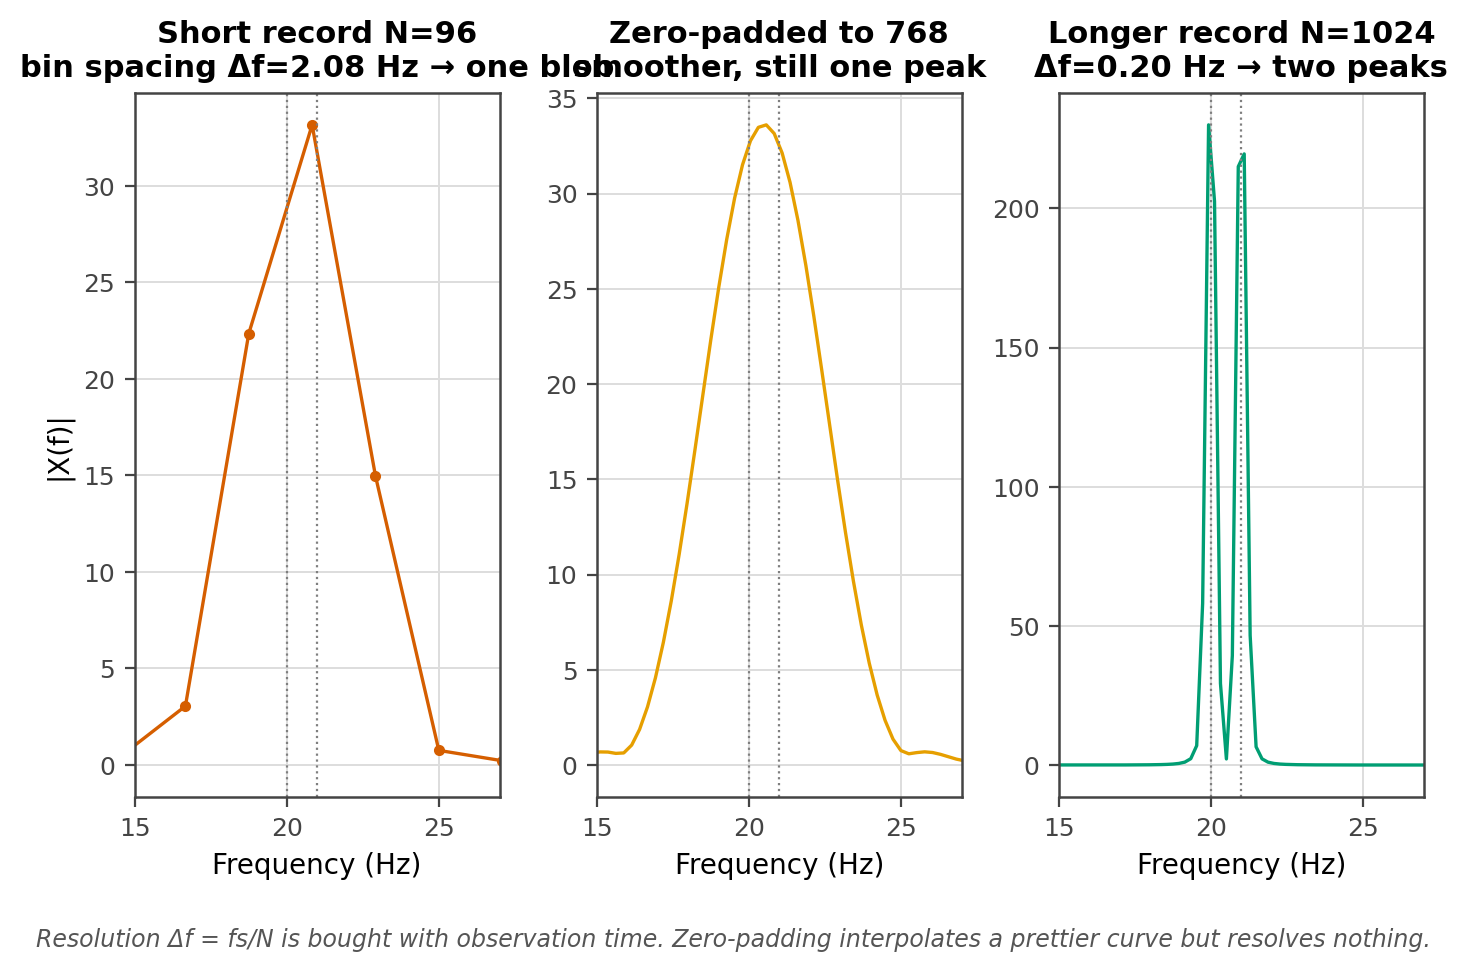

In [5]:
fs = 200.0
f1, f2 = 20.0, 21.0    # two close tones, 1.0 Hz apart
fig, ax = bs.newfig(w=7.2, h=4.6, nrows=1, ncols=3)

# (a) short record: bin spacing Δf = fs/N is coarse; too little DATA to resolve
N_short = 96
t = np.arange(N_short) / fs
x = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)
X = np.abs(np.fft.rfft(x * np.hanning(N_short)))
f = np.fft.rfftfreq(N_short, 1 / fs)
ax[0].plot(f, X, color=bs.C["red"], lw=1.2, marker="o", ms=3)
ax[0].set_title(f"Short record N={N_short}\nbin spacing Δf={fs/N_short:.2f} Hz → one blob")
ax[0].set_xlim(15, 27)

# (b) same short record, zero-padded 8x: smoother but NOT resolved
Npad = N_short * 8
Xz = np.abs(np.fft.rfft(x * np.hanning(N_short), n=Npad))
fz = np.fft.rfftfreq(Npad, 1 / fs)
ax[1].plot(fz, Xz, color=bs.C["orange"], lw=1.2)
ax[1].set_title(f"Zero-padded to {Npad}\nsmoother, still one peak")
ax[1].set_xlim(15, 27)

# (c) longer record: more DATA (a longer observation) resolves BOTH tones
N_long = 1024
t2 = np.arange(N_long) / fs
x2 = np.sin(2 * np.pi * f1 * t2) + np.sin(2 * np.pi * f2 * t2)
X2 = np.abs(np.fft.rfft(x2 * np.hanning(N_long)))
f2v = np.fft.rfftfreq(N_long, 1 / fs)
ax[2].plot(f2v, X2, color=bs.C["green"], lw=1.2)
ax[2].set_title(f"Longer record N={N_long}\nΔf={fs/N_long:.2f} Hz → two peaks")
ax[2].set_xlim(15, 27)
for a in ax:
    a.axvline(f1, color=bs.C["grey"], ls=":", lw=0.8)
    a.axvline(f2, color=bs.C["grey"], ls=":", lw=0.8)
    a.set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("|X(f)|")
bs.takeaway(fig, "Resolution Δf = fs/N is bought with observation time. "
                 "Zero-padding interpolates a prettier curve but resolves nothing.")
plt.tight_layout()
plt.show()

## 3.4  stft

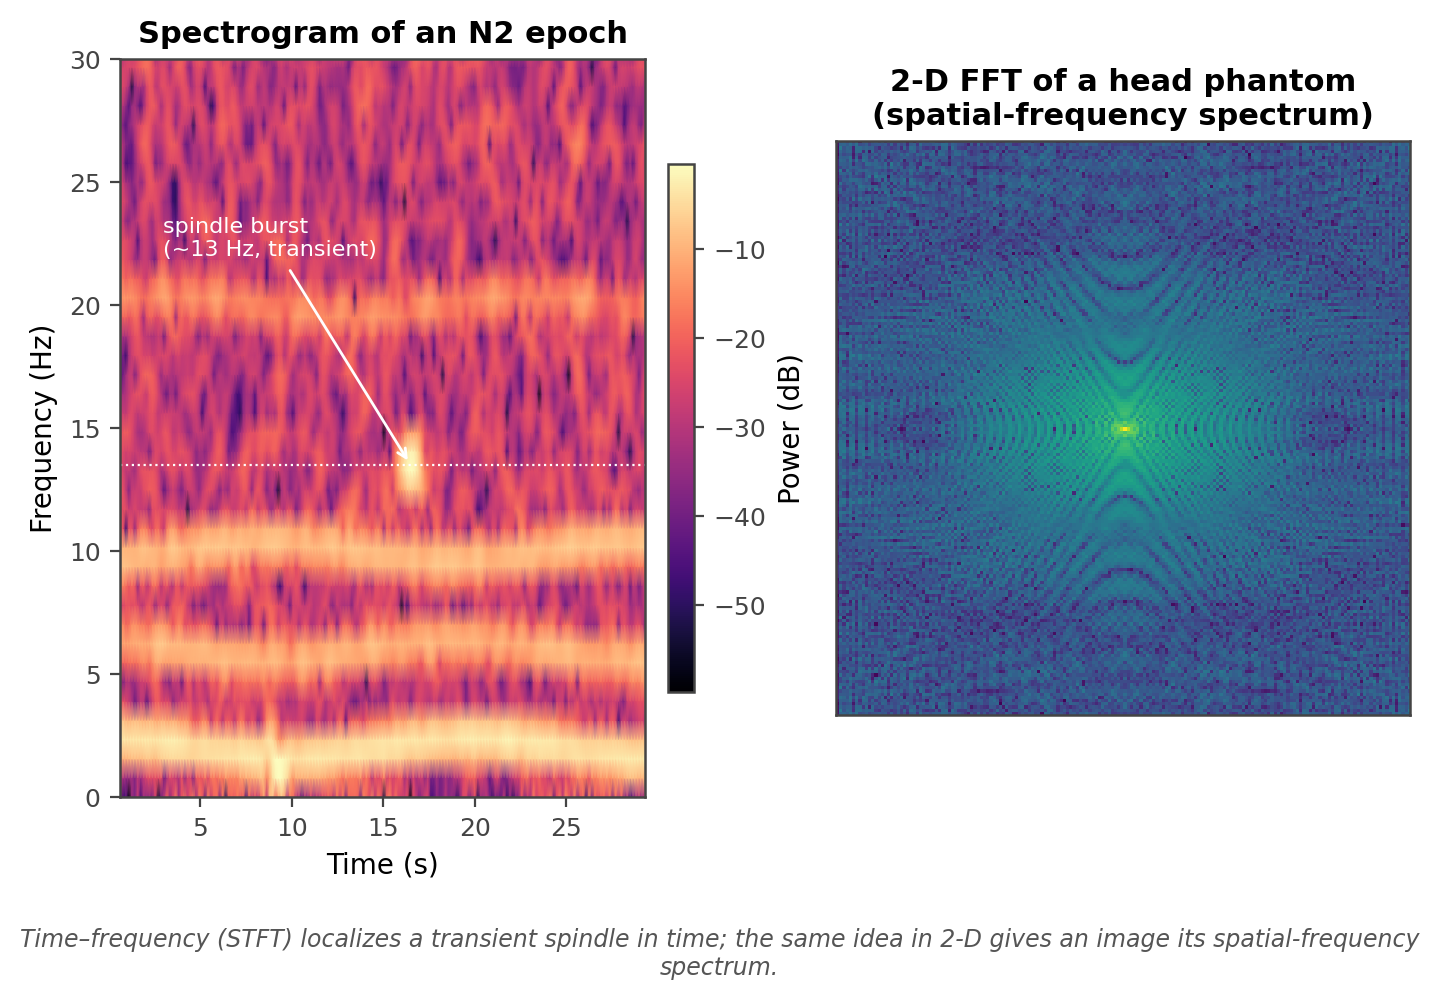

In [6]:
fs = 100.0
t, x = bio.eeg(duration=30.0, fs=fs, stage="N2")
f, tt, Sxx = sig.spectrogram(x, fs=fs, nperseg=128, noverlap=112,
                             window="hann", scaling="spectrum")
fig, ax = bs.newfig(w=7.2, h=4.6, nrows=1, ncols=2)
pc = ax[0].pcolormesh(tt, f, 10 * np.log10(Sxx + 1e-6), shading="gouraud",
                      cmap="magma")
ax[0].set_ylim(0, 30)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Frequency (Hz)")
ax[0].set_title("Spectrogram of an N2 epoch")
ax[0].axhline(13.5, color="white", ls=":", lw=0.8)
ax[0].annotate("spindle burst\n(~13 Hz, transient)", xy=(16.5, 13.5),
               xytext=(3, 22), color="white", fontsize=8,
               arrowprops=dict(arrowstyle="->", color="white"))
fig.colorbar(pc, ax=ax[0], label="Power (dB)", fraction=0.046, pad=0.04)
ax[0].grid(False)

# 2-D FFT of the head phantom
img = bio.head_phantom(size=180)
F = np.fft.fftshift(np.fft.fft2(img))
mag = np.log10(np.abs(F) + 1)
ax[1].imshow(mag, cmap="viridis")
ax[1].set_title("2-D FFT of a head phantom\n(spatial-frequency spectrum)")
ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].grid(False)
bs.takeaway(fig, "Time–frequency (STFT) localizes a transient spindle in time; "
                 "the same idea in 2-D gives an image its spatial-frequency spectrum.")
plt.tight_layout()
plt.show()

## 3.5  image fft mag phase

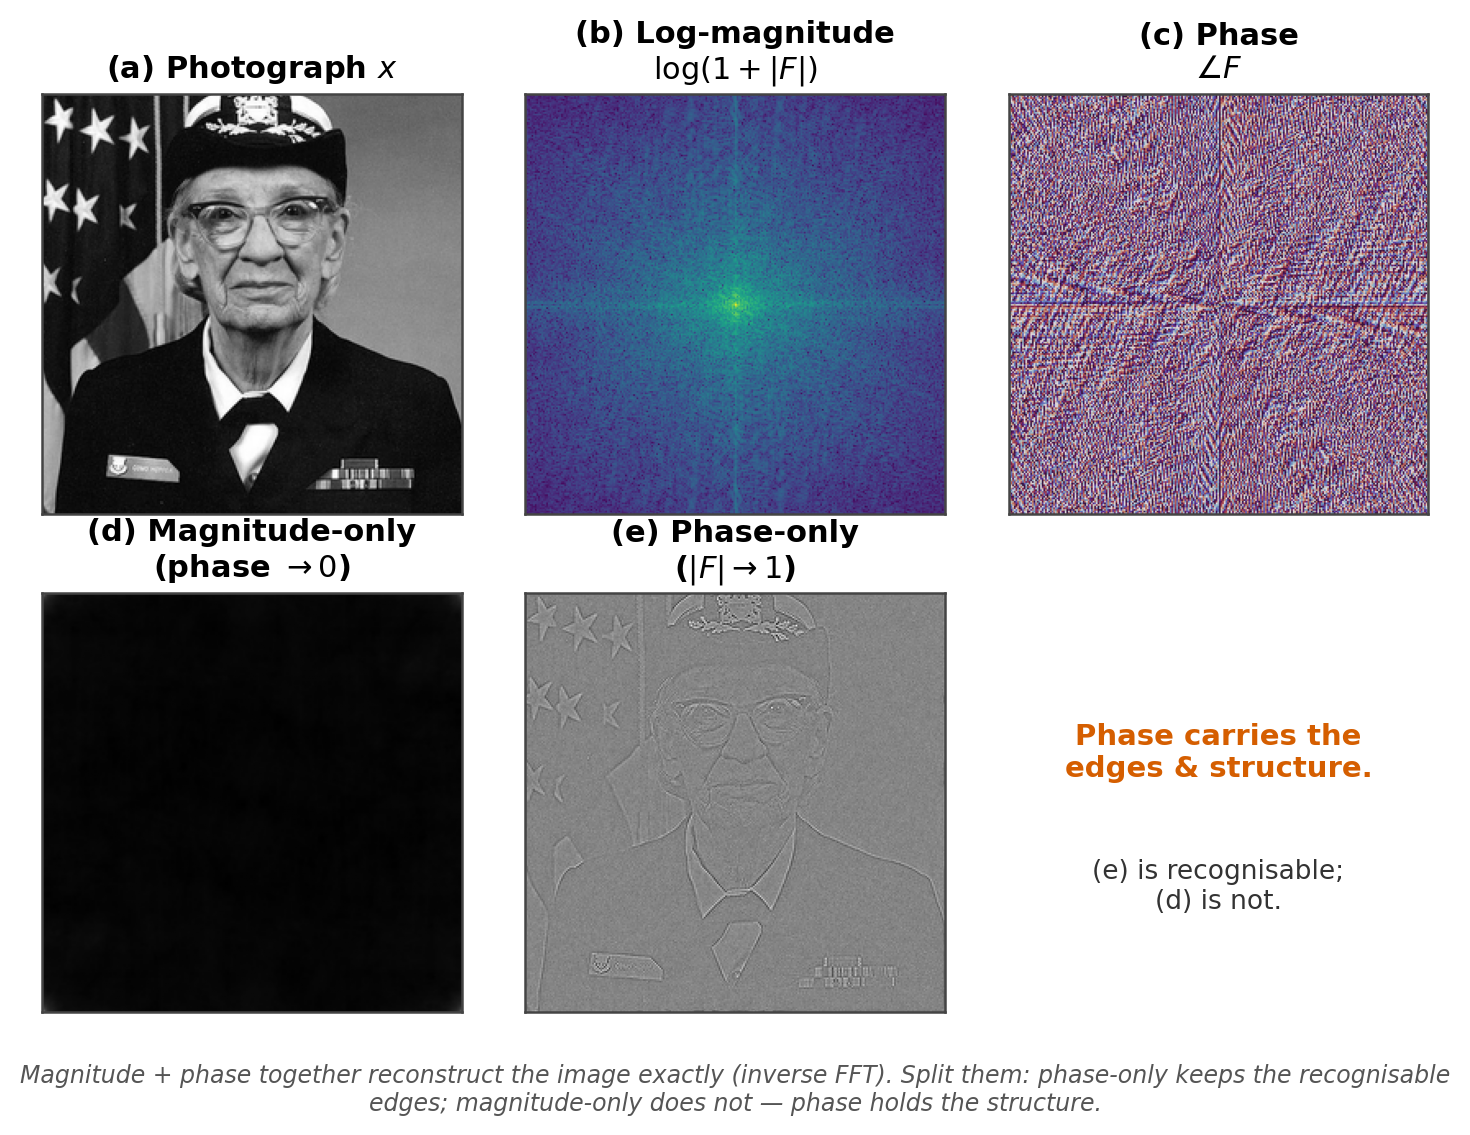

In [7]:
img = bio.test_photo(256)

# Full 2-D FFT (complex): magnitude AND phase together are lossless.
F = np.fft.fft2(img)
Fsh = np.fft.fftshift(F)
log_mag = np.log1p(np.abs(Fsh))          # log(1 + |F|) for display
phase = np.angle(Fsh)                     # phase spectrum in [-pi, pi]

# (d) MAGNITUDE-ONLY reconstruction: keep |F|, throw phase away (set to 0).
mag_only = np.abs(F)                       # phase = 0  <=>  real, non-negative
recon_mag = np.real(np.fft.ifft2(mag_only))

# (e) PHASE-ONLY reconstruction: keep phase, set magnitude to 1.
phase_only = np.exp(1j * np.angle(F))      # unit magnitude, original phase
recon_phase = np.real(np.fft.ifft2(phase_only))

def _stretch(a):
    a = a - a.min()
    return a / (a.max() + 1e-12)

fig, axes = bs.newfig(w=7.4, h=5.2, nrows=2, ncols=3)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("(a) Photograph $x$")

im1 = axes[0, 1].imshow(log_mag, cmap="viridis")
axes[0, 1].set_title("(b) Log-magnitude\n$\\log(1+|F|)$")

axes[0, 2].imshow(phase, cmap="twilight")
axes[0, 2].set_title("(c) Phase\n$\\angle F$")

axes[1, 0].imshow(_stretch(recon_mag), cmap="gray")
axes[1, 0].set_title("(d) Magnitude-only\n(phase $\\to 0$)")

axes[1, 1].imshow(_stretch(recon_phase), cmap="gray")
axes[1, 1].set_title("(e) Phase-only\n($|F| \\to 1$)")

# (f) verdict panel: text summarising the takeaway
axf = axes[1, 2]
axf.axis("off")
axf.text(0.5, 0.62,
         "Phase carries the\nedges & structure.",
         ha="center", va="center", fontsize=10.5, fontweight="bold",
         color=bs.C["red"], transform=axf.transAxes)
axf.text(0.5, 0.30,
         "(e) is recognisable;\n(d) is not.",
         ha="center", va="center", fontsize=9.5, color="#333333",
         transform=axf.transAxes)

bs.takeaway(fig, "Magnitude + phase together reconstruct the image exactly "
                 "(inverse FFT). Split them: phase-only keeps the recognisable "
                 "edges; magnitude-only does not — phase holds the structure.")
plt.tight_layout()
plt.show()

## 3.6  two domains

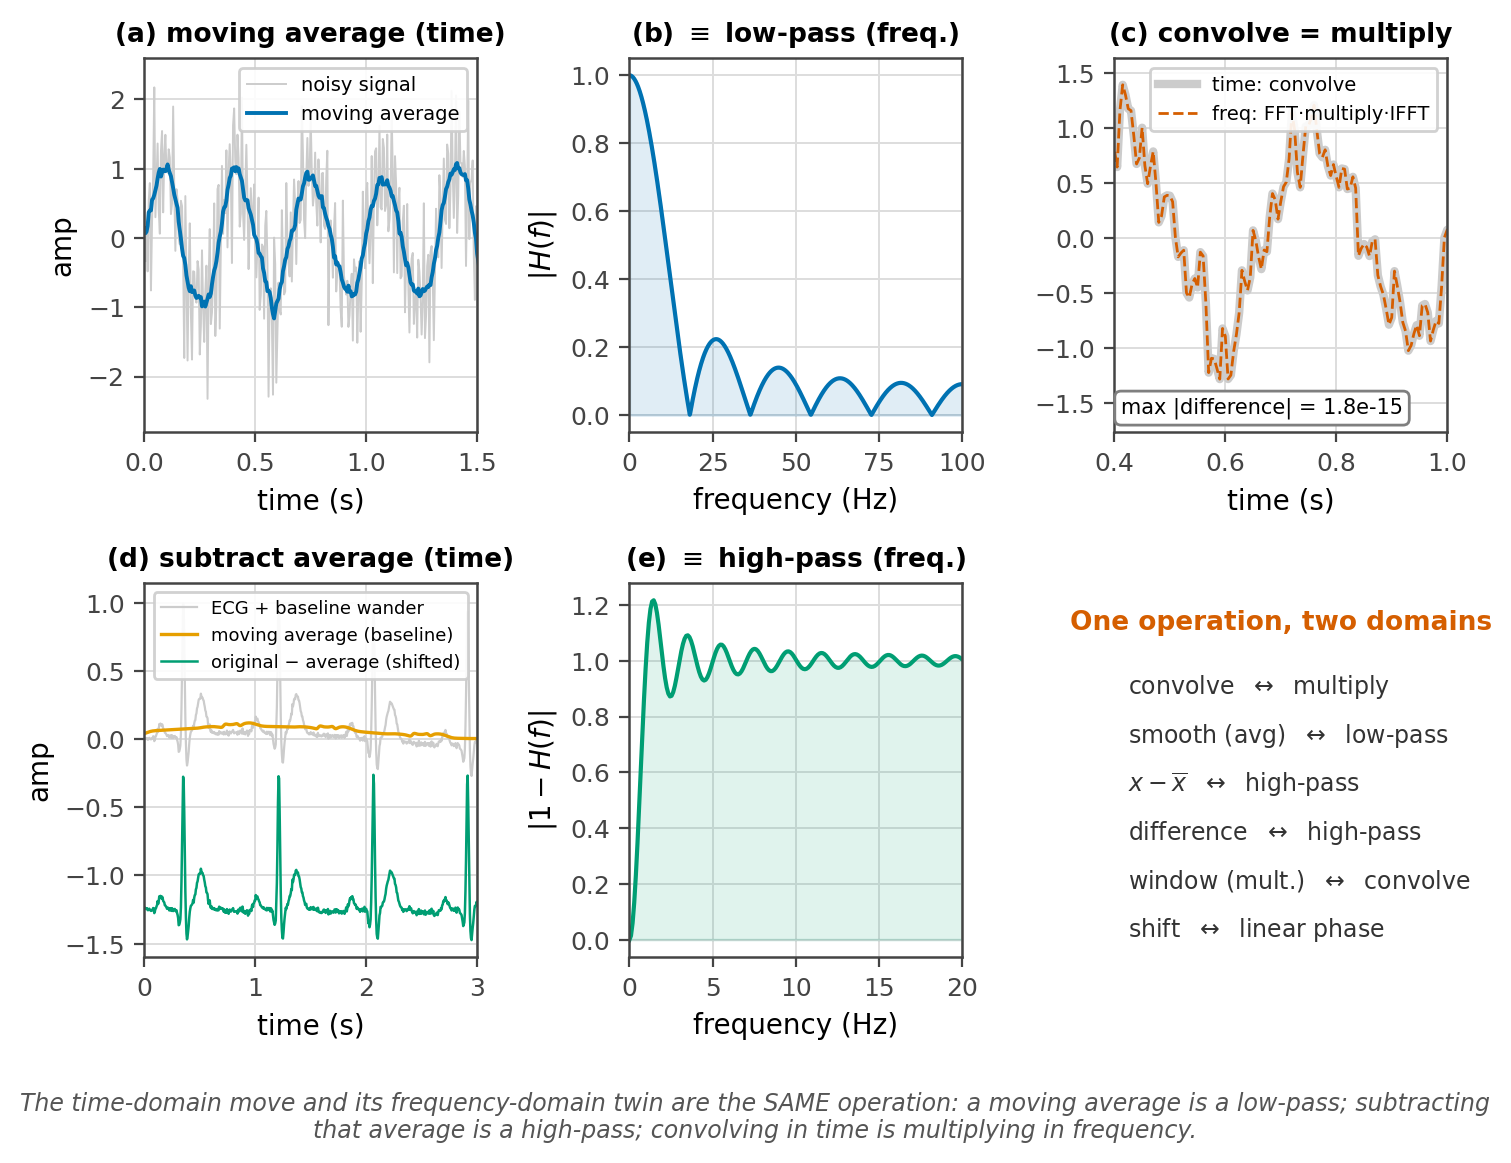

In [8]:
fs = 200.0
N = int(5 * fs)
t = np.arange(N) / fs

# ---- low-pass demo: slow signal + high-frequency noise, smoothed by a moving average
rng = np.random.default_rng(3)
slow = np.sin(2 * np.pi * 3 * t)
x_noisy = slow + 0.6 * np.sin(2 * np.pi * 55 * t) + 0.4 * rng.standard_normal(N)
M = 11
h = np.ones(M) / M                       # moving-average kernel
y_smooth = np.convolve(x_noisy, h, mode="same")

# ---- high-pass demo: ECG with baseline wander; original minus its moving average
te, ecg = bio.ecg(duration=5.0, fs=200, noise=0.01)
Mb = 199                                  # ~1 s window: well below the 1.2 Hz heart rate
hb = np.ones(Mb) / Mb
baseline = np.convolve(ecg, hb, mode="same")
ecg_hp = ecg - baseline                    # == (delta - h) * ecg  -> high-pass

# ---- frequency responses of the two kernels
Nf = 2048
f = np.fft.rfftfreq(Nf, 1 / fs)
H = np.abs(np.fft.rfft(h, Nf))             # low-pass (sinc)
# mode="same" convolution with a symmetric kernel is zero-phase (delay-free);
# rfft(hb, Nf) alone carries the causal kernel's own group delay (Mb-1)/2
# samples, so that phase must be removed before taking |1-H| or the response
# doesn't describe the filter actually applied above.
d = (Mb - 1) / 2
Hb = np.fft.rfft(hb, Nf) * np.exp(1j * 2 * np.pi * f * d / fs)
G = np.abs(1 - Hb)                          # high-pass = |1 - H_baseline|

# ---- convolution theorem: identical result two ways
ker = np.array([0.2, 0.5, 1.0, 0.5, 0.2]); ker = ker / ker.sum()
xseg = x_noisy
y_time = np.convolve(xseg, ker)                        # linear convolution in time
L = len(xseg) + len(ker) - 1
y_freq = np.real(np.fft.ifft(np.fft.fft(xseg, L) * np.fft.fft(ker, L)))
max_diff = np.max(np.abs(y_time - y_freq))

fig, ax = bs.newfig(w=7.6, h=5.4, nrows=2, ncols=3)

# (a) moving average in time
ax[0, 0].plot(t, x_noisy, color=bs.C["lightgrey"], lw=0.7, label="noisy signal")
ax[0, 0].plot(t, y_smooth, color=bs.C["blue"], lw=1.4, label="moving average")
ax[0, 0].set_xlim(0, 1.5)
ax[0, 0].set_title("(a) moving average (time)", fontsize=9.5)
ax[0, 0].set_xlabel("time (s)"); ax[0, 0].set_ylabel("amp")
ax[0, 0].legend(loc="upper right", fontsize=7)

# (b) == low-pass in frequency
ax[0, 1].plot(f, H, color=bs.C["blue"], lw=1.5)
ax[0, 1].fill_between(f, 0, H, color=bs.C["blue"], alpha=0.12)
ax[0, 1].set_title(r"(b) $\equiv$ low-pass (freq.)", fontsize=9.5)
ax[0, 1].set_xlabel("frequency (Hz)"); ax[0, 1].set_ylabel(r"$|H(f)|$")
ax[0, 1].set_xlim(0, 100)

# (c) convolution == multiplication (numerically identical)
tt = np.arange(len(y_time)) / fs
ax[0, 2].plot(tt, y_time, color=bs.C["lightgrey"], lw=3.0,
              label="time: convolve")
ax[0, 2].plot(tt, y_freq, color=bs.C["red"], lw=1.0, ls="--",
              label="freq: FFT·multiply·IFFT")
ax[0, 2].set_xlim(0.4, 1.0)
ax[0, 2].set_title("(c) convolve = multiply", fontsize=9.5)
ax[0, 2].set_xlabel("time (s)")
ax[0, 2].legend(loc="upper right", fontsize=7)
ax[0, 2].text(0.02, 0.05, f"max |difference| = {max_diff:.1e}",
              transform=ax[0, 2].transAxes, fontsize=7.5,
              bbox=dict(boxstyle="round", fc="white", ec=bs.C["grey"]))

# (d) subtract the moving average in time (baseline removal)
ax[1, 0].plot(te, ecg, color=bs.C["lightgrey"], lw=0.8, label="ECG + baseline wander")
ax[1, 0].plot(te, baseline, color=bs.C["orange"], lw=1.2, label="moving average (baseline)")
ax[1, 0].plot(te, ecg_hp - 1.2, color=bs.C["green"], lw=0.9, label="original − average (shifted)")
ax[1, 0].set_xlim(0, 3)
ax[1, 0].set_title("(d) subtract average (time)", fontsize=9.5)
ax[1, 0].set_xlabel("time (s)"); ax[1, 0].set_ylabel("amp")
ax[1, 0].legend(loc="upper right", fontsize=6.5)

# (e) == high-pass in frequency
ax[1, 1].plot(f, G, color=bs.C["green"], lw=1.5)
ax[1, 1].fill_between(f, 0, G, color=bs.C["green"], alpha=0.12)
ax[1, 1].set_title(r"(e) $\equiv$ high-pass (freq.)", fontsize=9.5)
ax[1, 1].set_xlabel("frequency (Hz)"); ax[1, 1].set_ylabel(r"$|1-H(f)|$")
ax[1, 1].set_xlim(0, 20)

# (f) verdict / dictionary panel
axf = ax[1, 2]; axf.axis("off")
axf.text(0.5, 0.93, "One operation, two domains",
         ha="center", va="top", fontsize=9.5, fontweight="bold",
         color=bs.C["red"], transform=axf.transAxes)
lines = [
    r"convolve  $\leftrightarrow$  multiply",
    r"smooth (avg)  $\leftrightarrow$  low-pass",
    r"$x-\overline{x}$  $\leftrightarrow$  high-pass",
    r"difference  $\leftrightarrow$  high-pass",
    r"window (mult.)  $\leftrightarrow$  convolve",
    r"shift  $\leftrightarrow$  linear phase",
]
for i, s in enumerate(lines):
    axf.text(0.04, 0.76 - i * 0.13, s, ha="left", va="top",
             fontsize=8.5, color="#333333", transform=axf.transAxes)

bs.takeaway(fig, "The time-domain move and its frequency-domain twin are the SAME "
                 "operation: a moving average is a low-pass; subtracting that average "
                 "is a high-pass; convolving in time is multiplying in frequency.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `X = fft(x)`; `spectrogram(x,win,ov,nfft,fs)`; `ifft(X)`.

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Add samples vs zero-pad two close tones — which one actually resolves them?

<details><summary>💡 Hint &amp; what you should see</summary>

Resolution Δf = fs/N is set by the **record length** (real samples). Zero-padding only interpolates the same spectrum (smoother, not sharper). Only adding **real** samples splits the two peaks.

</details>

**2.** Reconstruct an image from magnitude-only vs phase-only. Which is recognisable?

<details><summary>💡 Hint &amp; what you should see</summary>

**Phase** carries structure (edges, where things are); magnitude carries contrast. The phase-only reconstruction is recognisable; the magnitude-only one is not.

</details>

In [9]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch03_figures.py`.*